## Clustering (standalone scripts)

Use the Python modules for a clean workflow:

**1. Build cluster index** (run from `Carrie/` or `Sci4Sci/`):
```bash
python Carrie/build_cluster_index.py embeddings.pkl -o index.pkl --method leiden
python Carrie/build_cluster_index.py embeddings.pkl -o index.pkl --method kmeans --n_clusters 50
```

**2. Query top themes**:
```bash
python Carrie/query_themes.py embeddings.pkl index.pkl -o themes.json
python Carrie/query_themes.py embeddings.pkl index.pkl --corpus_ids 123,456 --topk 10
```

**Programmatic use**:
```python
from Carrie.clustering import build_index, query_themes
build_index("embeddings.pkl", "index.pkl", method="leiden")
themes = query_themes("embeddings.pkl", "index.pkl", corpus_ids=[123, 456])
```

# Modeling Hypergraphs of MEDLINE Journals

## Model

* Let $G=(V,E)$ be a hypergraph, where $E$ is the collection of hyperedges.
* Let $H$ be the collection of admissible combinations of nodes, (e.g., if we only consider hyperedges of size less than 10). 
* $G$ is modeled as a collection of random variables ${X_h: h\in H}$.
* $X_h\sim Poisson(\lambda_h)$.
* The mean $\lambda_h$ depends on the (latent) features of nodes in $h$: $$\lambda_h=\sum_k\prod_{i\in h}r_i\theta_{ik},$$ where $\theta_{ik}$ is the percentage of node $i$ in block $k$  ($\sum_{k}\theta_{ik}=1$), and $r_i$ corresponds to the popularity of node $i$.
* Assume $X_h$'s are independent of each other given $\theta=(\theta_i)$ and $r=(r_i)$.
* The distribution of $G$ is given by $$p(G|\theta)=\prod_{h\in H} p(x_h|\theta)$$.
* Estimation: Use stochastic gradient descent to estimate $\theta$ and $r$
    * Let $\theta_{ij}=\theta_{ij}r_i$, so that we only need to deal with one set of variables $\theta$.

## Workbench

In [2]:
import time
import pandas as pd
import scipy.sparse as ssp
import numpy as np
from multiprocessing import Pool, cpu_count
from scipy.stats import dirichlet
from collections import Counter
from datetime import datetime
import random
from collections import defaultdict
from scipy.optimize import minimize
from itertools import zip_longest
from numba import guvectorize,vectorize
from numba import int64,float64,int32
from numba import cuda
import math
import pickle as pickle
from scipy.stats import pearsonr
from sklearn.metrics import precision_recall_curve
from functools import partial
import json
import sys
import pandas as pd
import pickle
import numpy as np
import datasets
sys.path.insert(0, '/home/ymwan/Sci4Sci')  # or path to workspace root
sys.path.insert(0, '/home/ymwan/Sci4Sci/Carrie/prescience')
from CSPaperGraph.scripts.specter2_embed import specter2_embed_papers, _get_specter2_model
from dataset.compute_novelty_score import compute_novelty_scores
import os
import Carrie.prescience.utils as prescience_utils

In [3]:
%matplotlib inline
import pylab as plt
import seaborn as sns

In [4]:
class Stopwatch:
    start_time=None
    def go(self,msg=''):
        if msg:
            print(msg, flush=True)
        self.start_time=time.time()
    def stop(self,msg=''):
        if msg:
            print("{}: {} seconds".format(msg,time.time()-self.start_time), flush=True)
        else:
            print("Elapsed time: {} seconds".format(time.time()-self.start_time), flush=True)
    def check(self):
        return time.time()-self.start_time

tic=Stopwatch()

## Load data

In [5]:
def load_date(filename):
    tic=Stopwatch()
    print("Loading paper dates %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    A=pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    tic.stop()
    return A

def load_hypergraph(filename):
    tic=Stopwatch()
    print("Loading file %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    (row,col) = pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    A=ssp.coo_matrix((np.ones(len(row),dtype=np.int8),(row,col)),shape=(max(row)+1, max(col)+1),dtype=np.int8)
    tic.stop()
    return A

In [ ]:
input_file_path = "yuancarrieyjy/AI-arXiv"
df = datasets.load_dataset(input_file_path)


In [52]:
print("Filtering papers with target roles and building Citation Hypergraph")

# 1. Filter: drop rows with missing date
df_filtered = df.dropna(subset=['date']).copy()

# 2. Extract year
df_filtered['year'] = pd.to_datetime(df_filtered['date']).dt.year.astype(int)

# 3. Normalize roles to list and filter by target_roles
#    (match if any target_role is a substring of any role)
def has_target_role(roles):
    if roles is None or (isinstance(roles, (list, np.ndarray)) and len(roles) == 0):
        return False
    return 'target' in roles

df_filtered = df_filtered[df_filtered['roles'].apply(has_target_role)]
papers = df_filtered.to_dict(orient='records')

df_filtered["specter2_embed"] = specter2_embed_papers(papers)


Filtering papers with target roles and building Citation Hypergraph
Computing SPECTER 2.0 embeddings for 52836 papers on cuda


Computing SPECTER 2.0 embeddings: 100%|██████████| 1652/1652 [02:08<00:00, 12.82it/s]


In [53]:
# Do a Truncated SVD dimension reduction for df_filtered['specter2_embed'] to retrieve the top 100 basis?
from sklearn.decomposition import TruncatedSVD

emb_matrix = np.array(df_filtered['specter2_embed'].tolist(), dtype=np.float32)

n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
emb_reduced = svd.fit_transform(emb_matrix)

df_filtered[f'specter2_embed_{n_components}'] = list(emb_reduced)
basis_top_n = svd.components_  # shape (n, 768)

print(f"Explained variance ratio (top {n_components}): {svd.explained_variance_ratio_.sum():.4f}")



Explained variance ratio (top 50): 0.7632


In [54]:
df_filtered.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,year,specter2_embed,specter2_embed_50
386921,279403293,2410.01044,2024-10-01,RATIONALYST: Mining Implicit Rationales for Pr...,The reasoning steps generated by LLMs might be...,"[cs.AI, cs.CL]","[target, target.author.publication_history]","[{'corpus_id': '268385093', 'num_citations': 1...","[{'author_id': 'd jiang_20', 'name': 'Dongwei ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2024,"[0.1191609799861908, 1.0536303520202637, -0.71...","[20.118076, 4.737713, -0.5891838, -2.2177951, ..."
386922,273023004,2410.00629,2024-10-01,An Illumination-Robust Feature Extractor Augme...,"Visual features, whose description often relie...",[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '261822418', 'num_citations': 1...","[{'author_id': 's zhao_113', 'name': 'Shunyi Z...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]",2024,"[-0.5157613158226013, -0.2606130540370941, -0....","[19.812298, -5.5560656, 1.3696461, -2.1881065,..."
386923,273025680,2410.01028,2024-10-01,Draft on the Fly: Adaptive Self-Speculative De...,We present a simple on the fly method for fast...,[cs.CL],"[target, target.author.publication_history]","[{'corpus_id': '8928715', 'num_citations': 233...","[{'author_id': 'm metel_1', 'name': 'Michael [...","[0, 0, 0, 0, 0, 2, 3, 4, 4, 4, 4, 5, 5, 7]",2024,"[0.03284074366092682, 0.7663933038711548, -0.5...","[20.534435, 3.2388878, 1.7206722, 2.2307544, -..."
386924,273022927,2410.00903,2024-10-01,Causal Representation Learning with Generative...,"In this paper, we demonstrate how to enhance t...","[stat.AP, cs.CL, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '237440146', 'num_citations': 6...","[{'author_id': 'k imai_1', 'name': 'Kosuke Ima...","[1, 1, 1, 1, 2, 4, 4, 4, 6, 6, 8, 9, 11, 12]",2024,"[0.3873628079891205, 0.9645597338676453, -0.44...","[19.984825, 2.2123964, -1.0378892, 0.679571, 0..."
386925,273186169,2410.03739,2024-10-01,"Grammar Induction from Visual, Speech and Text",Grammar Induction could benefit from rich hete...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '102350747', 'num_citations': 1...","[{'author_id': 'y zhao_156', 'name': 'Yu Zhao'...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]",2024,"[0.6491087675094604, 0.9163593649864197, 0.459...","[20.480373, 1.1786765, 3.8781776, 0.5648347, -..."


In [55]:
emb_matrix = np.array(df_filtered['specter2_embed'].tolist(), dtype=np.float32)

In [56]:
import os
import sys
import argparse
from typing import Optional, List, Dict, Any
from collections import defaultdict

import numpy as np
from tqdm import tqdm

# Add prescience package root for utils
import Carrie.prescience.utils as prescience_utils


In [57]:
import numpy as np
import igraph as ig
import leidenalg
import faiss
from scipy.sparse import coo_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

def l2_normalize(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def build_knn(X, k=30, use_gpu=False):
    d = X.shape[1]
    index = faiss.IndexFlatIP(d)  # inner product on normalized vectors = cosine similarity

    if use_gpu:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)

    index.add(X)
    scores, nbrs = index.search(X, k + 1)  # include self
    return scores[:, 1:], nbrs[:, 1:]      # drop self

def knn_to_sparse_graph(nbrs, scores, min_sim=0.5, symmetrize=True):
    n, k = nbrs.shape
    row = np.repeat(np.arange(n), k)
    col = nbrs.reshape(-1)
    data = scores.reshape(-1)

    keep = data >= min_sim
    row, col, data = row[keep], col[keep], data[keep]

    G = coo_matrix((data, (row, col)), shape=(n, n)).tocsr()

    if symmetrize:
        G = G.maximum(G.T)

    return G

def csr_to_igraph(G):
    sources, targets = G.nonzero()
    weights = G[sources, targets].A1 if hasattr(G[sources, targets], "A1") else G[sources, targets]
    g = ig.Graph(n=G.shape[0], edges=list(zip(sources.tolist(), targets.tolist())), directed=False)
    g.es["weight"] = weights.tolist()
    return g


def soft_membership_for_paper(i, nbrs, scores, labels):
    weights = defaultdict(float)
    for j, s in zip(nbrs[i], scores[i]):
        weights[labels[j]] += float(s)
    total = sum(weights.values())
    return {c: w / total for c, w in sorted(weights.items(), key=lambda x: -x[1])}

def top_terms(texts, top_n=10):
    vec = TfidfVectorizer(stop_words="english", max_features=5000)
    X_text = vec.fit_transform(texts)
    scores = np.asarray(X_text.mean(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = scores.argsort()[::-1][:top_n]
    return vocab[top_idx].tolist()

def nearest_themes(query_embedding, index, labels, topk=50):
    q = query_embedding.astype(np.float32)
    q = q / max(np.linalg.norm(q), 1e-12)
    scores, nbrs = index.search(q[None], topk)

    theme_scores = {}
    for j, s in zip(nbrs[0], scores[0]):
        c = labels[j]
        theme_scores[c] = theme_scores.get(c, 0.0) + float(s)

    total = sum(theme_scores.values())
    ranked = sorted(theme_scores.items(), key=lambda x: -x[1])
    return [(c, s / total) for c, s in ranked]


In [14]:
def generate_cluster_embeddings(emb_matrix, seed=42, k=30, resolution_parameter=2.0, min_sim=0.55, symmetrize=True):
    # 1. normalize
    X = l2_normalize(emb_matrix.astype(np.float32))
    np.random.seed(seed)

    # 2. knn
    scores, nbrs = build_knn(X, k)

    # 3. graph
    G = knn_to_sparse_graph(nbrs, scores, min_sim, symmetrize=symmetrize)

    # 4. communities
    g = csr_to_igraph(G)
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=resolution_parameter,
        seed=seed,
    )
    labels = np.array(partition.membership)

    # 5. soft membership for each paper
    soft_membership = []
    for i in range(len(X)):
        soft_membership.append(soft_membership_for_paper(i, nbrs, scores, labels))
    
    return labels, soft_membership
    

In [58]:
labels, soft_membership = generate_cluster_embeddings(emb_matrix, seed=42, k=30, resolution_parameter=2.0, min_sim=0.55, symmetrize=True)
print(len(np.unique(labels)))
print(soft_membership[:5])
df_filtered['primary_cluster'] = labels
df_filtered['soft_membership'] = soft_membership

38
[{np.int64(7): 0.9001631006193158, np.int64(27): 0.09983689938068419}, {np.int64(3): 0.833485173516243, np.int64(11): 0.16651482648375707}, {np.int64(0): 0.933486833697235, np.int64(9): 0.06651316630276503}, {np.int64(15): 0.9667596767238733, np.int64(9): 0.03324032327612667}, {np.int64(2): 0.36677561198393116, np.int64(17): 0.29976148874475683, np.int64(10): 0.23347424839126535, np.int64(9): 0.03351111104667107, np.int64(0): 0.03325740414470959, np.int64(22): 0.03322013568866601}]


In [59]:
df_filtered.head(20)

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,year,specter2_embed,specter2_embed_50,primary_cluster,soft_membership
386921,279403293,2410.01044,2024-10-01,RATIONALYST: Mining Implicit Rationales for Pr...,The reasoning steps generated by LLMs might be...,"[cs.AI, cs.CL]","[target, target.author.publication_history]","[{'corpus_id': '268385093', 'num_citations': 1...","[{'author_id': 'd jiang_20', 'name': 'Dongwei ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2024,"[0.1191609799861908, 1.0536303520202637, -0.71...","[20.118076, 4.737713, -0.5891838, -2.2177951, ...",7,"{7: 0.9001631006193158, 27: 0.09983689938068419}"
386922,273023004,2410.00629,2024-10-01,An Illumination-Robust Feature Extractor Augme...,"Visual features, whose description often relie...",[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '261822418', 'num_citations': 1...","[{'author_id': 's zhao_113', 'name': 'Shunyi Z...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]",2024,"[-0.5157613158226013, -0.2606130540370941, -0....","[19.812298, -5.5560656, 1.3696461, -2.1881065,...",3,"{3: 0.833485173516243, 11: 0.16651482648375707}"
386923,273025680,2410.01028,2024-10-01,Draft on the Fly: Adaptive Self-Speculative De...,We present a simple on the fly method for fast...,[cs.CL],"[target, target.author.publication_history]","[{'corpus_id': '8928715', 'num_citations': 233...","[{'author_id': 'm metel_1', 'name': 'Michael [...","[0, 0, 0, 0, 0, 2, 3, 4, 4, 4, 4, 5, 5, 7]",2024,"[0.03284074366092682, 0.7663933038711548, -0.5...","[20.534435, 3.2388878, 1.7206722, 2.2307544, -...",0,"{0: 0.933486833697235, 9: 0.06651316630276503}"
386924,273022927,2410.00903,2024-10-01,Causal Representation Learning with Generative...,"In this paper, we demonstrate how to enhance t...","[stat.AP, cs.CL, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '237440146', 'num_citations': 6...","[{'author_id': 'k imai_1', 'name': 'Kosuke Ima...","[1, 1, 1, 1, 2, 4, 4, 4, 6, 6, 8, 9, 11, 12]",2024,"[0.3873628079891205, 0.9645597338676453, -0.44...","[19.984825, 2.2123964, -1.0378892, 0.679571, 0...",15,"{15: 0.9667596767238733, 9: 0.03324032327612667}"
386925,273186169,2410.03739,2024-10-01,"Grammar Induction from Visual, Speech and Text",Grammar Induction could benefit from rich hete...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '102350747', 'num_citations': 1...","[{'author_id': 'y zhao_156', 'name': 'Yu Zhao'...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]",2024,"[0.6491087675094604, 0.9163593649864197, 0.459...","[20.480373, 1.1786765, 3.8781776, 0.5648347, -...",2,"{2: 0.36677561198393116, 17: 0.299761488744756..."
386926,273026020,2410.00944,2024-10-01,GAMMA-PD: Graph-based Analysis of Multi-Modal ...,The rapid advancement of medical technology ha...,"[q-bio.QM, cs.AI, cs.LG, eess.IV, q-bio.NC]","[target, target.author.publication_history]","[{'corpus_id': '235458394', 'num_citations': 1...","[{'author_id': 'f nerrise_1', 'name': 'Favour ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2024,"[0.3123379647731781, 0.8605023622512817, -0.32...","[20.099213, -0.34633106, -0.5115694, -0.178759...",4,"{4: 0.7339616250145251, 30: 0.1995922324788305..."
386930,273023143,2410.00900,2024-10-01,OSSA: Unsupervised One-Shot Style Adaptation,"Despite their success in various vision tasks,...",[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '253397461', 'num_citations': 8...","[{'author_id': 'r gerster_0', 'name': 'Robin G...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",2024,"[0.20217254757881165, 0.16224245727062225, -0....","[20.375753, -3.4692745, 2.7547565, 0.9164448, ...",16,"{16: 0.8337784469900287, 28: 0.066522370044428..."
386932,273026288,2410.01091,2024-10-01,Efficient and Private Marginal Reconstruction ...,Differential privacy is the dominant standard ...,"[cs.LG, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': 

In [60]:
# Show top representative papers per cluster (closest to cluster centroid)
import Carrie.prescience.clustering.cluster_embeddings as cluster_embeddings
emb_matrix = np.array(df_filtered['specter2_embed'].tolist(), dtype=np.float32)

k_examples = 5 # number of example papers per cluster
max_clusters_show = 15  # show first N clusters; None for all

rep = cluster_embeddings.top_representative_papers(
    np.asarray(emb_matrix, dtype=np.float64), labels, k=k_examples
)
clusters_to_show = sorted(rep.keys())[:max_clusters_show] if max_clusters_show else sorted(rep.keys())

for cid in clusters_to_show:
    indices = rep[cid]
    size = (labels == cid).sum()
    print(f"\n--- Cluster {cid} (n={size}) ---")
    for i, idx in enumerate(indices):
        row = df_filtered.iloc[idx]
        title = (row.get("title") or "") + ("..." if len(str(row.get("title", ""))) > 80 else "")
        abstract = (row.get("abstract") or "") + ("..." if len(str(row.get("abstract", ""))) > 100 else "")
        print(f"  {i+1}. {title}")
        print(f"    Abstract: {abstract}")


--- Cluster 0 (n=3287) ---
  1. Lillama: Large Language Models Compression via Low-Rank Feature Distillation
    Abstract: Current LLM structured pruning methods typically involve two steps: (1) compression with calibration data and (2) costly continued pretraining on billions of tokens to recover lost performance. This second step is necessary as the first significantly impacts model accuracy. Prior research suggests pretrained Transformer weights aren't inherently low-rank, unlike their activations, which may explain this drop. Based on this observation, we propose Lillama, a compression method that locally distills activations with low-rank weights. Using SVD for initialization and a joint loss combining teacher and student activations, we accelerate convergence and reduce memory use with local gradient updates. Lillama compresses Mixtral-8x7B within minutes on a single A100 GPU, removing 10 billion parameters while retaining over 95% of its original performance. Phi-2 3B can be co

t-SNE on 10000 points


/tmp/ipykernel_1632883/1595611916.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/tmp/ipykernel_1632883/1595611916.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


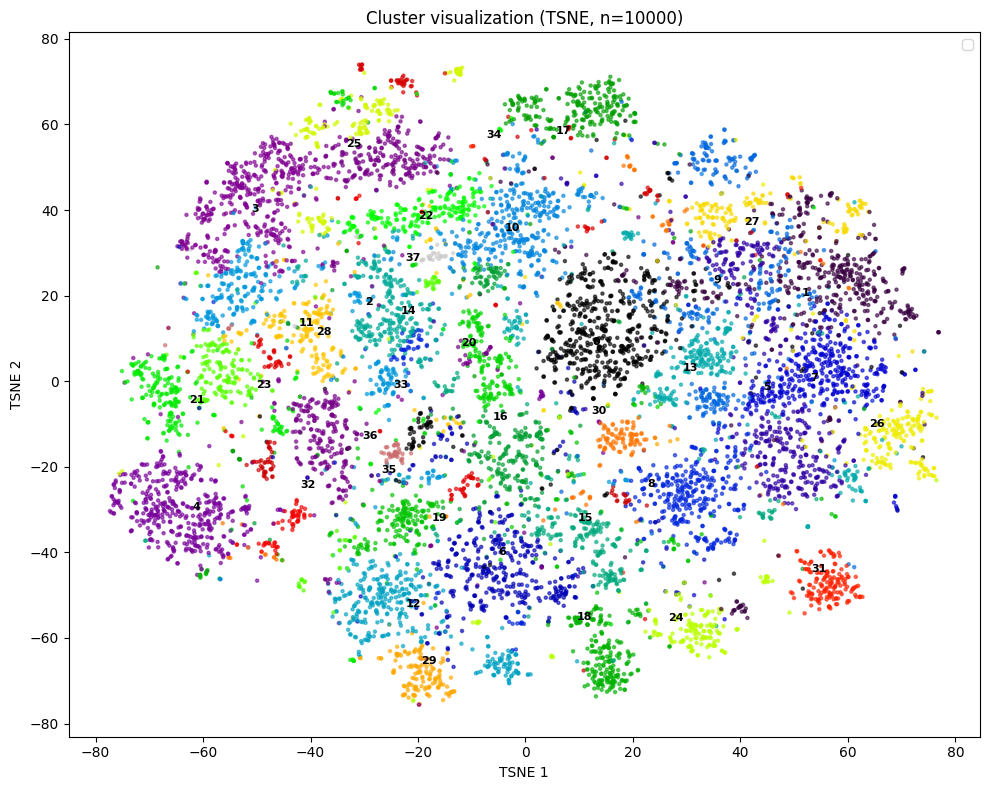

PCA: explained variance 18.51%


/tmp/ipykernel_1632883/1595611916.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
/tmp/ipykernel_1632883/1595611916.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


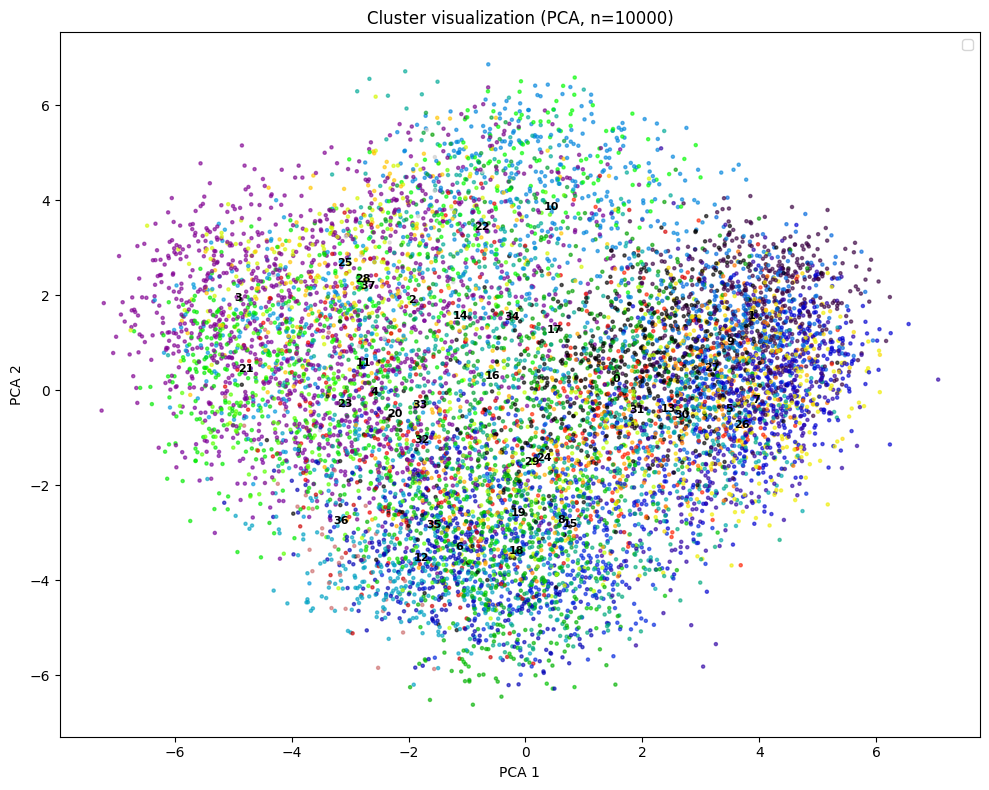

In [61]:
# Visualize clusters in 2D using PCA or t-SNE, colored by cluster
# method: "pca" (fast) or "tsne" (slower, often better separation)

def plot_clusters(emb_matrix, labels, method="tsne", max_points=10000):
    max_points = 10000  # subsample for t-SNE if slow; None for full data

    X = np.asarray(emb_matrix, dtype=np.float64)
    n_plot = len(X) if max_points is None else min(max_points, len(X))
    if n_plot < len(X):
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X), n_plot, replace=False)
        X_plot, labels_plot = X[idx], np.array(labels)[idx]
    else:
        X_plot, labels_plot = X, np.array(labels)

    if method == "pca":
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X_plot)
        print(f"PCA: explained variance {reducer.explained_variance_ratio_.sum():.2%}")
    else:
        from sklearn.manifold import TSNE
        X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_plot)
        print(f"t-SNE on {n_plot} points")

    # Plot: noise (-1) in gray, clusters in distinct colors
    fig, ax = plt.subplots(figsize=(10, 8))
    noise_mask = labels_plot == -1
    cluster_mask = ~noise_mask

    if noise_mask.any():
        ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1], c="lightgray", s=5, alpha=0.5, label="noise")
    if cluster_mask.any():
        scatter = ax.scatter(X_2d[cluster_mask, 0], X_2d[cluster_mask, 1], c=labels_plot[cluster_mask], s=5, alpha=0.6, cmap="nipy_spectral")
        ax.legend(loc="upper right")
        # Add cluster numbers at centroids
        for cid in np.unique(labels_plot[cluster_mask]):
            mask_c = labels_plot == cid
            cx, cy = X_2d[mask_c, 0].mean(), X_2d[mask_c, 1].mean()
            ax.annotate(str(int(cid)), (cx, cy), fontsize=8, ha="center", va="center", fontweight="bold")
    ax.set_title(f"Cluster visualization ({method.upper()}, n={n_plot})")
    ax.set_xlabel(f"{method.upper()} 1")
    ax.set_ylabel(f"{method.upper()} 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_clusters(emb_matrix, labels, method="tsne", max_points=10000)
plot_clusters(emb_matrix, labels, method="pca", max_points=10000)

In [63]:
df_filtered.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,year,specter2_embed,specter2_embed_50,primary_cluster,soft_membership,citation_12m
386921,279403293,2410.01044,2024-10-01,RATIONALYST: Mining Implicit Rationales for Pr...,The reasoning steps generated by LLMs might be...,"[cs.AI, cs.CL]","[target, target.author.publication_history]","[{'corpus_id': '268385093', 'num_citations': 1...","[{'author_id': 'd jiang_20', 'name': 'Dongwei ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",2024,"[0.1191609799861908, 1.0536303520202637, -0.71...","[20.118076, 4.737713, -0.5891838, -2.2177951, ...",7,"{7: 0.9001631006193158, 27: 0.09983689938068419}",NaN
386922,273023004,2410.00629,2024-10-01,An Illumination-Robust Feature Extractor Augme...,"Visual features, whose description often relie...",[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '261822418', 'num_citations': 1...","[{'author_id': 's zhao_113', 'name': 'Shunyi Z...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]",2024,"[-0.5157613158226013, -0.2606130540370941, -0....","[19.812298, -5.5560656, 1.3696461, -2.1881065,...",3,"{3: 0.833485173516243, 11: 0.16651482648375707}",NaN
386923,273025680,2410.01028,2024-10-01,Draft on the Fly: Adaptive Self-Speculative De...,We present a simple on the fly method for fast...,[cs.CL],"[target, target.author.publication_history]","[{'corpus_id': '8928715', 'num_citations': 233...","[{'author_id': 'm metel_1', 'name': 'Michael [...","[0, 0, 0, 0, 0, 2, 3, 4, 4, 4, 4, 5, 5, 7]",2024,"[0.03284074366092682, 0.7663933038711548, -0.5...","[20.534435, 3.2388878, 1.7206722, 2.2307544, -...",0,"{0: 0.933486833697235, 9: 0.06651316630276503}",NaN
386924,273022927,2410.00903,2024-10-01,Causal Representation Learning with Generative...,"In this paper, we demonstrate how to enhance t...","[stat.AP, cs.CL, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '237440146', 'num_citations': 6...","[{'author_id': 'k imai_1', 'name': 'Kosuke Ima...","[1, 1, 1, 1, 2, 4, 4, 4, 6, 6, 8, 9, 11, 12]",2024,"[0.3873628079891205, 0.9645597338676453, -0.44...","[19.984825, 2.2123964, -1.0378892, 0.679571, 0...",15,"{15: 0.9667596767238733, 9: 0.03324032327612667}",NaN
386925,273186169,2410.03739,2024-10-01,"Grammar Induction from Visual, Speech and Text",Grammar Induction could benefit from rich hete...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '102350747', 'num_citations': 1...","[{'author_id': 'y zhao_156', 'name': 'Yu Zhao'...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]",2024,"[0.6491087675094604, 0.9163593649864197, 0.459...","[20.480373, 1.1786765, 3.8781776, 0.5648347, -...",2,"{2: 0.36677561198393116, 17: 0.299761488744756...",NaN


In [ ]:


def _to_embedding_array(emb) -> np.ndarray:
    """Convert embedding (list, array, or dict with 'key') to 1D float32 array."""
    if isinstance(emb, dict) and "key" in emb:
        emb = emb["key"]
    arr = np.asarray(emb, dtype=np.float32).ravel()
    return arr


def partition_by_date(papers: List[Dict[str, Any]]) -> Dict[str, List[Dict]]:
    """Partition papers by date string. Returns sorted dict date -> list of papers."""
    date2papers = defaultdict(list)
    for p in papers:
        d = p.get("date")
        if d is None or (isinstance(d, float) and np.isnan(d)):
            continue
        date2papers[str(d)].append(p)
    return dict(sorted(date2papers.items()))


# TODO: Only use past_papers for novelty computation
def compute_novelty_scores(
    target_papers: List[Dict[str, Any]],
    embedding_key: str = "specter2_embed",
    k: int = 5,
    distance_metric: str = "cosine",
    exclude_self: bool = True,
    past_papers: List[Dict[str, Any]] = None,
) -> Dict[Any, float]:
    """
    Compute novelty for each paper as mean distance to k nearest prior papers.

    Args:
        papers: List of paper dicts with 'date', embedding_key, and 'corpus_id'
        embedding_key: Column name for embeddings (default: specter2_embed)
        k: Number of nearest prior neighbors
        distance_metric: 'cosine' or 'l2'
        exclude_self: Exclude same paper from prior (for same-date ties)

    Returns:
        Dict mapping corpus_id -> novelty score (float). Higher = more novel.
    """
    if all_papers is None:
        all_papers = target_papers

    def _valid_papers(papers):
        out = []
        for p in papers:
            if p.get("date") is None:
                continue
            emb = p.get(embedding_key)
            if emb is None:
                continue
            try:
                arr = _to_embedding_array(emb)
                if arr.size == 0:
                    continue
            except (ValueError, TypeError):
                continue
            out.append(p)
        return out

    valid_target = _valid_papers(target_papers)
    valid_all = _valid_papers(all_papers)

    if len(valid_target) == 0:
        return {}

    date2papers_target = partition_by_date(valid_target)
    date2papers_all = partition_by_date(valid_all)
    if len(date2papers_target) == 0:
        return {}

    # Build corpus_id -> embedding from ALL papers (for prior index and query vectors)
    cid2emb = {}
    for p in valid_all:
        cid2emb[p["corpus_id"]] = _to_embedding_array(p[embedding_key])

    novelty = {}
    sorted_dates_all = sorted(date2papers_all.keys())
    sorted_dates_target = sorted(date2papers_target.keys())

    for date_key in tqdm(sorted_dates_target, desc="Computing novelty"):
        bucket_papers = date2papers_target[date_key]

        # Prior = all papers (from all_papers) strictly before date_key
        prior_embeddings = {}
        for d in sorted_dates_all:
            if d >= date_key:
                break
            for p in date2papers_all[d]:
                cid = p["corpus_id"]
                if cid in cid2emb:
                    prior_embeddings[cid] = cid2emb[cid]

        k_actual = min(k, len(prior_embeddings))
        if k_actual == 0:
            for p in bucket_papers:
                novelty[p["corpus_id"]] = float("nan")
            continue

        # Build FAISS index for prior
        prior_index = prescience_utils.create_index(prior_embeddings, distance_metric)

        # Query each paper in bucket
        query_ids = [p["corpus_id"] for p in bucket_papers if p["corpus_id"] in cid2emb]
        query_vecs = [cid2emb[cid] for cid in query_ids]

        if len(query_vecs) == 0:
            for p in bucket_papers:
                novelty[p["corpus_id"]] = float("nan")
        else:
            retrieved_ids, scores = prescience_utils.query_index(
                prior_index, query_vecs, k_actual
            )

            # For cosine: FAISS returns similarity (inner product). Distance = 1 - sim.
            # For l2: FAISS returns squared L2 distance.
            for qid, neighbor_ids, raw in zip(query_ids, retrieved_ids, scores):
                # Filter out self and invalid
                distances = []
                for nid, r in zip(neighbor_ids, raw):
                    if nid is None or (exclude_self and nid == qid):
                        continue
                    if np.isnan(r):
                        continue
                    if distance_metric == "cosine":
                        dist = float(1.0 - r)
                    else:
                        dist = float(np.sqrt(max(0, r)))
                    distances.append(dist)
                if len(distances) > 0:
                    novelty[qid] = float(np.mean(distances))
                else:
                    novelty[qid] = float("nan")

            for p in bucket_papers:
                if p["corpus_id"] not in novelty:
                    novelty[p["corpus_id"]] = float("nan")

    return novelty



In [64]:
def get_citation_percentile(corpus_id, df, months=12, n_bins=5):
    """
    Get the citation percentile bin (1-5) for a paper based on 12-month citations.
    
    Args:
        corpus_id: Paper corpus ID
        df: DataFrame with 'corpus_id' and 'citation_trajectory' columns
        months: Number of months for citation count (default 12)
        n_bins: Number of percentile bins (default 5)
    
    Returns:
        int 1-5: Percentile bin (1=lowest 20%, 5=highest 20%), or None if invalid
    """
    row = df[df['corpus_id'] == corpus_id]
    if row.empty:
        return None
    traj = row['citation_trajectory'].iloc[0]
    if traj is None or len(traj) < months:
        return None
    citation_12m = traj[months - 1]
    
    # Compute 12-month citations for all valid papers
    def _get_12m(x):
        if x is None or (not hasattr(x, '__len__')) or len(x) < months: return np.nan
        return x[months - 1]
    citations_12m = df['citation_trajectory'].apply(_get_12m).dropna()
    if len(citations_12m) == 0:
        return None
    
    # Percentile cutoffs for 5 bins: 20th, 40th, 60th, 80th
    cutoffs = np.percentile(citations_12m, [20, 40, 60, 80])
    print(cutoffs)
    if citation_12m <= cutoffs[0]: return 1
    if citation_12m <= cutoffs[1]: return 2
    if citation_12m <= cutoffs[2]: return 3
    if citation_12m <= cutoffs[3]: return 4
    return 5

# Add citation_percentile column to df_filtered
df_filtered['citation_12m'] = df_filtered['citation_trajectory'].apply(
    lambda x: x[11] if x is not None and len(x) >= 12 else np.nan
)
_cutoffs = np.percentile(df_filtered['citation_12m'].dropna(), [10, 20, 30, 40, 50, 60, 70, 80, 90])
def _bin_val(c):
    if np.isnan(c): return np.nan
    if c <= _cutoffs[0]: return 1
    if c <= _cutoffs[1]: return 2
    if c <= _cutoffs[2]: return 3
    if c <= _cutoffs[3]: return 4
    if c <= _cutoffs[4]: return 5   
    if c <= _cutoffs[5]: return 6
    if c <= _cutoffs[6]: return 7
    if c <= _cutoffs[7]: return 8
    if c <= _cutoffs[8]: return 9
    return 10
df_filtered['citation_percentile'] = df_filtered['citation_12m'].apply(_bin_val)
print(f"Citation percentile bins with cutoffs {_cutoffs}: {df_filtered['citation_percentile'].value_counts().sort_index().to_dict()}")

Citation percentile bins with cutoffs [ 0.  0.  1.  1.  2.  3.  5.  7. 13.]: {1.0: 2435, 3.0: 1943, 5.0: 1301, 6.0: 935, 7.0: 1219, 8.0: 715, 9.0: 968, 10.0: 948}


In [65]:
# Compute novelty scores: avg distance to k nearest prior papers in embedding space
# Prior context = all_papers; novelty computed only for target_papers (df_filtered)
target_papers = df_filtered.to_dict(orient='records')
novelty_dict = compute_novelty_scores(target_papers, embedding_key='specter2_embed', k=5, distance_metric='cosine')
df_filtered['novelty'] = [novelty_dict.get(p['corpus_id'], np.nan) for p in target_papers]
print(f"Novelty: mean={np.nanmean(df_filtered['novelty']):.4f}, std={np.nanstd(df_filtered['novelty']):.4f}")

Computing novelty: 100%|██████████| 365/365 [00:58<00:00,  6.24it/s]

Novelty: mean=0.0570, std=0.0144


In [72]:
# 5. Convert back to Dataset, update split, and push
ds_joined = Dataset.from_pandas(df_joined, preserve_index=False)
ds_test_joined = Dataset.from_pandas(df_test_joined, preserve_index=False)
ds_dict[split] = ds_joined
ds_dict["test"] = ds_test_joined
print(f"Uploading to {REPO_ID} ({split}: {len(df_joined)} rows)...")
ds_dict.push_to_hub(REPO_ID)
print("Done.")

Uploading to yuancarrieyjy/PreScience-augmented (test: 373716 rows)...


Uploading the dataset shards:   0%|          | 0/3 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /tmp/tmp0yde1ygs.parquet              :  14%|#4        | 89.4MB /  637MB            

Done.


In [71]:
df_test_joined.dropna(subset=['citation_percentile']).head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,specter2_embed,primary_cluster,soft_membership,novelty,citation_percentile
386921,279403293,2410.01044,2024-10-01,RATIONALYST: Mining Implicit Rationales for Pr...,The reasoning steps generated by LLMs might be...,"[cs.AI, cs.CL]","[target, target.author.publication_history]","[{'corpus_id': '268385093', 'num_citations': 1...","[{'author_id': 'd jiang_20', 'h_index': 2.0, '...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0.1191609799861908, 1.0536303520202637, -0.71...",7.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.90016310...",NaN,1.0
386922,273023004,2410.00629,2024-10-01,An Illumination-Robust Feature Extractor Augme...,"Visual features, whose description often relie...",[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '261822418', 'num_citations': 1...","[{'author_id': 's zhao_113', 'h_index': 1.0, '...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]","[-0.5157613158226013, -0.2606130540370941, -0....",3.0,"[0.0, 0.0, 0.0, 0.833485173516243, 0.0, 0.0, 0...",NaN,3.0
386923,273025680,2410.01028,2024-10-01,Draft on the Fly: Adaptive Self-Speculative De...,We present a simple on the fly method for fast...,[cs.CL],"[target, target.author.publication_history]","[{'corpus_id': '8928715', 'num_citations': 233...","[{'author_id': 'm metel_1', 'h_index': 5.0, 'n...","[0, 0, 0, 0, 0, 2, 3, 4, 4, 4, 4, 5, 5, 7]","[0.03284074366092682, 0.7663933038711548, -0.5...",0.0,"[0.933486833697235, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",NaN,7.0
386924,273022927,2410.00903,2024-10-01,Causal Representation Learning with Generative...,"In this paper, we demonstrate how to enhance t...","[stat.AP, cs.CL, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '237440146', 'num_citations': 6...","[{'author_id': 'k imai_1', 'h_index': 48.0, 'n...","[1, 1, 1, 1, 2, 4, 4, 4, 6, 6, 8, 9, 11, 12]","[0.3873628079891205, 0.9645597338676453, -0.44...",15.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,9.0
386925,273186169,2410.03739,2024-10-01,"Grammar Induction from Visual, Speech and Text",Grammar Induction could benefit from rich hete...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '102350747', 'num_citations': 1...","[{'author_id': 'y zhao_156', 'h_index': 5.0, '...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]","[0.6491087675094604, 0.9163593649864197, 0.459...",2.0,"[0.03325740414470959, 0.0, 0.36677561198393116...",NaN,3.0


In [ ]:
# Correlation: novelty score vs citation_percentile=10 (top 20% citations)
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

df_valid = df_filtered.dropna(subset=['novelty', 'citation_percentile'])

# 1. Mean novelty: citation_percentile=5 vs others
novelty_top5 = df_valid[df_valid['citation_percentile'] == 10]['novelty']
novelty_other = df_valid[df_valid['citation_percentile'] != 10]['novelty']
print("Mean novelty by citation_percentile=5 vs others:")
print(f"  citation_percentile=5: mean={novelty_top5.mean():.4f}, n={len(novelty_top5)}")
print(f"  others (1-4):          mean={novelty_other.mean():.4f}, n={len(novelty_other)}")
stat, pval = mannwhitneyu(novelty_top5, novelty_other, alternative='two-sided')
print(f"  Mann-Whitney U test p-value: {pval:.4e}")

# 2. Spearman correlation: novelty vs citation_percentile (1-5 ordinal)
rho, p_spear = pearsonr(df_valid['novelty'], df_valid['citation_percentile'])
print(f"\Pearson rho(novelty, citation_percentile): {rho:.4f}, p={p_spear:.4e}")

# 3. Mean novelty by each bin
print("\nMean novelty by citation_percentile bin:")
for b in sorted(df_valid['citation_percentile'].unique()):
    m = df_valid[df_valid['citation_percentile'] == b]['novelty'].mean()
    n = (df_valid['citation_percentile'] == b).sum()
    mean_citation = df_valid[df_valid['citation_percentile'] == b]['citation_12m'].mean()
    print(f"  bin {b}: mean={m:.4f}, n={n}, mean_citation={mean_citation:.4f}")

Mean novelty by citation_percentile=5 vs others:
  citation_percentile=5: mean=0.0510, n=1016
  others (1-4):          mean=0.0502, n=9169
  Mann-Whitney U test p-value: 3.2353e-02
\Pearson rho(novelty, citation_percentile): 0.0045, p=6.5306e-01

Mean novelty by citation_percentile bin:
  bin 1.0: mean=0.0499, n=1238, mean_citation=0.0000
  bin 2.0: mean=0.0510, n=1133, mean_citation=1.0000
  bin 3.0: mean=0.0498, n=899, mean_citation=2.0000
  bin 4.0: mean=0.0502, n=1290, mean_citation=3.4620
  bin 5.0: mean=0.0503, n=912, mean_citation=5.4682
  bin 6.0: mean=0.0507, n=672, mean_citation=7.4717
  bin 7.0: mean=0.0495, n=1154, mean_citation=10.7314
  bin 8.0: mean=0.0497, n=879, mean_citation=16.5233
  bin 9.0: mean=0.0504, n=992, mean_citation=28.5494
  bin 10.0: mean=0.0510, n=1016, mean_citation=118.3947


In [ ]:
# calculate entropy of interdisciplinarity
n_clusters = len(set(df_filtered['primary_cluster'].unique()))
def get_entropy(soft_membership):
    soft_membership_array = np.array(list(soft_membership.values()))
    return -np.sum(soft_membership_array * np.log(soft_membership_array))

# calculate pairwise combination surprise
def get_combination_surprise(soft_membership_1, soft_membership_2):
    soft_membership_1_array = np.array([soft_membership_1.get(i, 0.0) for i in range(n_clusters)])
    soft_membership_2_array = np.array([soft_membership_2.get(i, 0.0) for i in range(n_clusters)])
    epsilon = 1e-10
    return np.sum(soft_membership_1_array * soft_membership_2_array * np.log(soft_membership_1_array * soft_membership_2_array + epsilon))


df_valid['entropy'] = df_valid['soft_membership'].apply(get_entropy)
df_valid['combination_surprise'] = df_valid.apply(lambda row: get_combination_surprise(row['soft_membership'], row['soft_membership']), axis=1)


/tmp/ipykernel_1162234/983555302.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['entropy'] = df_valid['soft_membership'].apply(get_entropy)
/tmp/ipykernel_1162234/983555302.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['combination_surprise'] = df_valid.apply(lambda row: get_combination_surprise(row['soft_membership'], row['soft_membership']), axis=1)


In [ ]:
len(df_valid)

10185

In [ ]:
for column in ["novelty", "primary_cluster", "entropy", "combination_surprise"]:
    rho, p_spear = pearsonr(df_valid['citation_percentile'] == 10, df_valid[column])
    print(f"\nPearson rho(citation_percentile = 10, {column}): {rho:.4f}, p={p_spear:.4e}")


Pearson rho(citation_percentile = 10, novelty): 0.0199, p=4.4830e-02

Pearson rho(citation_percentile = 10, primary_cluster): 0.0171, p=8.3743e-02

Pearson rho(citation_percentile = 10, entropy): 0.0072, p=4.6942e-01

Pearson rho(citation_percentile = 10, combination_surprise): -0.0096, p=3.3053e-01


In [ ]:
def get_citation_percentile(corpus_id, df, months=12, n_bins=5):
    """
    Get the citation percentile bin (1-5) for a paper based on 12-month citations.
    
    Args:
        corpus_id: Paper corpus ID
        df: DataFrame with 'corpus_id' and 'citation_trajectory' columns
        months: Number of months for citation count (default 12)
        n_bins: Number of percentile bins (default 5)
    
    Returns:
        int 1-5: Percentile bin (1=lowest 20%, 5=highest 20%), or None if invalid
    """
    row = df[df['corpus_id'] == corpus_id]
    if row.empty:
        return None
    traj = row['citation_trajectory'].iloc[0]
    if traj is None or len(traj) < months:
        return None
    citation_12m = traj[months - 1]
    
    # Compute 12-month citations for all valid papers
    def _get_12m(x):
        if x is None or (not hasattr(x, '__len__')) or len(x) < months: return np.nan
        return x[months - 1]
    citations_12m = df['citation_trajectory'].apply(_get_12m).dropna()
    if len(citations_12m) == 0:
        return None
    
    # Percentile cutoffs for 5 bins: 20th, 40th, 60th, 80th
    cutoffs = np.percentile(citations_12m, [20, 40, 60, 80])
    print(cutoffs)
    if citation_12m <= cutoffs[0]: return 1
    if citation_12m <= cutoffs[1]: return 2
    if citation_12m <= cutoffs[2]: return 3
    if citation_12m <= cutoffs[3]: return 4
    return 5

# Add citation_percentile column to df_filtered
df_filtered['citation_12m'] = df_filtered['citation_trajectory'].apply(
    lambda x: x[11] if x is not None and len(x) >= 12 else np.nan
)
_cutoffs = np.percentile(df_filtered['citation_12m'].dropna(), [10, 20, 30, 40, 50, 60, 70, 80, 90])
def _bin_val(c):
    if np.isnan(c): return np.nan
    if c <= _cutoffs[0]: return 1
    if c <= _cutoffs[1]: return 2
    if c <= _cutoffs[2]: return 3
    if c <= _cutoffs[3]: return 4
    if c <= _cutoffs[4]: return 5   
    if c <= _cutoffs[5]: return 6
    if c <= _cutoffs[6]: return 7
    if c <= _cutoffs[7]: return 8
    if c <= _cutoffs[8]: return 9
    return 10
df_filtered['citation_percentile'] = df_filtered['citation_12m'].apply(_bin_val)
print(f"Citation percentile bins with cutoffs {_cutoffs}: {df_filtered['citation_percentile'].value_counts().sort_index().to_dict()}")

Citation percentile bins with cutoffs [ 0.  0.  1.  1.  2.  3.  4.  6. 12.]: {1: 12224, 3: 8270, 5: 5380, 6: 3827, 7: 2747, 8: 3622, 9: 4576, 10: 4344}


In [ ]:
print(_cutoffs)

[ 0.  0.  1.  1.  2.  3.  4.  6. 12.]


In [ ]:
input_file_path = "allenai/prescience"
split = "test"
df_test = datasets.load_dataset(input_file_path, split=split).to_pandas()
df_test.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory
0,55712766,math/9201203,1989-10-26,Convex bodies with few faces,"It is proved that if $u_1,\ldots, u_n$ are vec...","[math.MG, math.FA]",[target.author.publication_history.key_reference],None,None,None
1,121266415,math/9201206,1989-11-09,On the volume of the intersection of two $L_p^...,"This note deals with the following problem, th...","[math.FA, math.MG]",[target.author.publication_history.key_reference],None,None,None
2,18202490,hep-th/9108004,1991-08-16,Ground Ring Of Two Dimensional String Theory,String theories with two dimensional space-tim...,[hep-th],[target.author.publication_history.key_reference],None,None,None
3,17420406,hep-th/9108005,1991-08-19,Fusion Residues,We discuss when and how the Verlinde dimension...,[hep-th],[target.author.publication_history.key_reference],None,None,None
4,5565132,hep-th/9111025,1991-11-12,Picard-Fuchs equations and mirror maps for hyp...,We describe a strategy for computing Yukawa co...,"[hep-th, math.AG]",[target.author.publication_history.key_reference],None,None,None


In [ ]:
path = "/home/ymwan/Sci4Sci/Carrie/prescience/data/corpus/test/all_papers.specter2_embeddings.pkl"
with open(path, 'rb') as f:
    corpusid2specter2_embed = pickle.load(f)
    corpusid2specter2_embed = corpusid2specter2_embed["data"]

df_test['specter2_embed'] = df_test['corpus_id'].map(lambda x: corpusid2specter2_embed[x]['key'])



In [ ]:
from datasets import Dataset, DatasetDict

In [ ]:
def cluster_umap_hdbscan(
    embeddings: np.ndarray,
    n_neighbors: int = 15,
    min_cluster_size: int = 5,
    min_samples: int = None,
    n_components: int = 10,
    random_state: int = 42,
    metric: str = 'cosine',
    **kwargs,
) -> np.ndarray:
    """
    Reduce dimensionality with UMAP, then cluster with HDBSCAN.
    Returns cluster labels; -1 denotes noise/outliers in HDBSCAN.
    """
    import umap
    import hdbscan
    from sklearn.preprocessing import normalize
    
    embeddings = normalize(embeddings)
    
    reduced = embeddings

    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        random_state=random_state,
        metric=metric,
        **kwargs,
    )
    reduced = reducer.fit_transform(reduced)
    reduced = np.asarray(reduced, dtype=np.float64)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=metric,
        algorithm="generic",
        **kwargs,
    )
    labels = clusterer.fit_predict(reduced)
    return labels

In [ ]:
# Parameter search: find UMAP+HDBSCAN settings that minimize noise points
# Uses a subsample for speed; run best params on full data afterward
import Carrie.prescience.dataset.embeddings.cluster_embeddings as cluster_embeddings
import itertools
from tqdm import tqdm

# Subsample for faster search (set to None to use full data - slower)
n_search = 8000
rng = np.random.default_rng(42)
if n_search and len(emb_matrix) > n_search:
    idx = rng.choice(len(emb_matrix), n_search, replace=False)
    emb_search = emb_matrix[idx]
    print(f"Parameter search on subsample of {n_search} (full data: {len(emb_matrix)})")
else:
    emb_search = emb_matrix
    print(f"Parameter search on full data: {len(emb_matrix)}")

# Grid: smaller min_cluster_size -> fewer noise; n_neighbors/n_components affect structure
param_grid = {
    "min_cluster_size": [3, 5, 8],
    "n_neighbors": [30, 50],
    "n_components": [30, 50],
}
keys = list(param_grid.keys())
grid = list(itertools.product(*(param_grid[k] for k in keys)))

results = []
for params in tqdm(grid, desc="Parameter search"):
    kw = dict(zip(keys, params))
    kw["min_samples"] = kw["min_cluster_size"]
    kw["random_state"] = 42
    try:
        labels = cluster_umap_hdbscan(
                                                        **kw)
        n_noise = (labels == -1).sum()
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        pct_noise = 100.0 * n_noise / len(labels)
        results.append({**kw, "n_noise": n_noise, "n_clusters": n_clusters, "pct_noise": pct_noise})
    except Exception as e:
        results.append({**kw, "n_noise": np.nan, "n_clusters": np.nan, "pct_noise": np.nan, "error": str(e)})

# Sort by n_noise ascending (fewest noise first)
results_df = pd.DataFrame(results).sort_values("n_noise")
print("\nTop 5 parameter sets (fewest noise):")
print(results_df.head().to_string(index=False))
best = results_df.iloc[0]
print(f"\nBest params: min_cluster_size={best['min_cluster_size']}, n_neighbors={best['n_neighbors']}, n_components={best['n_components']}")
print(f"  -> {int(best['n_noise'])} noise ({best['pct_noise']:.1f}%), {int(best['n_clusters'])} clusters")

ModuleNotFoundError: No module named 'Carrie.prescience.dataset.embeddings.cluster_embeddings'

In [ ]:
# Run best params on full data (run after parameter search above)
if "results_df" in globals() and len(results_df) > 0:
    best_params = results_df.iloc[0]
    print(f"Applying best params {best_params} to full data ({len(emb_matrix)} points)...")
    labels = cluster_umap_hdbscan(
        emb_matrix,
        n_neighbors=int(best_params["n_neighbors"]),
        min_cluster_size=int(best_params["min_cluster_size"]),
        min_samples=int(best_params["min_cluster_size"]),
        n_components=int(best_params["n_components"]),
        random_state=42,
    )
    stats = cluster_embeddings.print_cluster_statistics(labels)
    print(stats)
else:
    print("Run the parameter search cell above first.")

Applying best params min_cluster_size       8.0000
n_neighbors           30.0000
n_components          30.0000
min_samples            8.0000
random_state          42.0000
n_noise             2959.0000
n_clusters           114.0000
pct_noise             36.9875
Name: 8, dtype: float64 to full data (44990 points)...


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Cluster statistics:
  Papers with noise label (-1): 23391
  Cluster size: min=8, max=467, avg=42.7
{'n_noise': 23391, 'min_size': 8, 'max_size': 467, 'avg_size': 42.68577075098814, 'n_clusters': 506}


In [ ]:
import Carrie.prescience.dataset.embeddings.cluster_embeddings as cluster_embeddings
import importlib

importlib.reload(cluster_embeddings)
min_cluster_size = 5

labels = cluster_embeddings.cluster_umap_hdbscan(
            emb_matrix,
            n_neighbors=50,
            min_cluster_size=min_cluster_size,
            min_samples=min_cluster_size,
            n_components=n_components,
            random_state=42,
        )


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"Clustered {len(labels)} embeddings with: {n_clusters_found} clusters, {n_noise} noise points")

Clustered 44990 embeddings with: 733 clusters, 23320 noise points


In [ ]:
# Build corpus_id -> soft_membership dict and save as pickle
# Soft membership: for each paper, KNN-weighted distribution over clusters
import pickle
from collections import defaultdict

# Compute soft membership for each paper
corpus_ids = df_filtered["corpus_id"].astype(str).tolist()
num_clusters = len(np.unique(labels))

corpus_id2soft = {
    corpus_ids[i]: {int(c): soft_membership[i][c] for c in soft_membership[i]}
    for i in range(len(corpus_ids))
}

out_path = "../Data/corpus_id2soft_membership.pkl"
with open(out_path, "wb") as f:
    pickle.dump((labels, corpus_id2soft), f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Saved {len(corpus_id2soft)} corpus_id -> soft_membership to {out_path}")

Saved 44990 corpus_id -> soft_membership to ../Data/corpus_id2soft_membership.pkl


(44990, 768)

In [ ]:
# Define “surprising combination of ideas”

# A. Rarity of the whole topic mixture


42

In [ ]:

# B. Pairwise combination surprise

# C. High-entropy interdisciplinarity



In [ ]:
# Use a time-aware design

In [ ]:
cluster_df, centroids = cluster_basic_stats(X, labels)
print(cluster_df, centroids)

    cluster_id  num_papers  fraction_of_corpus  mean_sim_to_centroid  \
0            0        2131            0.047366             20.656846   
1            1        2006            0.044588             20.752110   
2            2        2003            0.044521             20.840453   
3            3        1988            0.044188             20.520585   
4            4        1911            0.042476             20.830713   
5            5        1876            0.041698             20.904511   
6            6        1867            0.041498             20.761407   
7            7        1862            0.041387             20.945379   
8            8        1657            0.036830             20.853036   
9            9        1377            0.030607             20.826929   
10          10        1342            0.029829             20.855506   
11          11        1323            0.029407             20.781561   
12          12        1319            0.029318             21.00

In [ ]:

df_filtered.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,year,specter2_embed,specter2_embed_100,paper_id
301079,263334020,2310.00749,2023-10-01,SEED: Domain-Specific Data Curation With Large...,Data curation tasks that prepare data for anal...,"[cs.DB, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '248965029', 'num_citations': 4...","[{'author_id': 'z chen_21', 'name': 'Zui Chen'...","[0, 0, 0, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, ...",2023,"[-0.1380254179239273, 0.08523871004581451, -0....","[20.259533, 4.135659, -0.9842603, -0.5026891, ...",263334020
301080,263334340,2310.00664,2023-10-01,Twin Neural Network Improved k-Nearest Neighbo...,Twin neural network regression is trained to p...,[cs.LG],[target],"[{'corpus_id': '229923810', 'num_citations': 2...","[{'author_id': 's wetzel_1', 'name': 'Sebastia...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2023,"[-0.35620176792144775, 0.3798765540122986, -0....","[20.392921, -0.84763014, 2.489703, -0.3924893,...",263334340
301082,263605418,2310.00808,2023-10-01,Completing Visual Objects via Bridging Generat...,This paper presents a novel approach to object...,[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '232307022', 'num_citations': 1...","[{'author_id': 'x li_350', 'name': 'Xiang Li',...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 3, 3, 3, 3, 3, ...",2023,"[0.02672574482858181, 0.21438473463058472, -0....","[20.388008, -4.496597, -2.539946, 0.42869884, ...",263605418
301083,263608648,2310.01444,2023-10-01,Adapting LLM Agents with Universal Feedback in...,Recent advances in large language models (LLMs...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '246411621', 'num_citations': 1...","[{'author_id': 'k wang_9', 'name': 'Kuan Wang'...","[0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 3, 4, 4, 4, ...",2023,"[-0.061554476618766785, 0.4036337435245514, -0...","[20.564978, 4.2823725, 0.02926904, 1.7597666, ...",263608648
301086,263334162,2310.00646,2023-10-01,Source Attribution for Large Language Model-Ge...,The impressive performances of Large Language ...,"[cs.LG, cs.AI, stat.ML]","[target, target.author.publication_history, ta...","[{'corpus_id': '141496572', 'num_citations': 6...","[{'author_id': 'j wang_392', 'name': 'Jingtan ...","[0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 5, 5, 8, 9, 9, ...",2023,"[0.5380525588989258, 0.7842212319374084, -0.82...","[20.400715, 1.5586095, 0.0019883513, -3.420540...",263334162


In [ ]:
df_filtered['paper_id'] = df_filtered['corpus_id'].astype(str)
df_long = df_filtered.explode('cited_ids').dropna(subset=['cited_ids'])

# 6. Deduplicate (paper_id, cited_id) pairs
df_long = df_long[['paper_id', 'cited_ids', 'year']].drop_duplicates()

# 7. Assign integer IDs via factorize (preserves order)
df_long['row_id'] = pd.Categorical(df_long['paper_id']).codes
df_long['col_id'] = pd.Categorical(df_long['cited_ids']).codes

# 8. Build outputs
rows = df_long['row_id'].values
cols = df_long['col_id'].values

# paper_dates_list: one date per unique paper (by row order)
paper_dates_list = df_long.groupby('paper_id')['year'].first().reindex(
    pd.Categorical(df_long['paper_id']).categories
).values

# Optional: explicit id mappings (for compatibility)
paper_id_to_id = {pid: i for i, pid in enumerate(pd.Categorical(df_long['paper_id']).categories)}
cited_paper_to_id = {cid: i for i, cid in enumerate(pd.Categorical(df_long['cited_ids']).categories)}

if len(rows) > 0:
    print(f"Built hypergraph with {len(paper_id_to_id)} papers and {len(cited_paper_to_id)} unique cited papers.")
    # Save if needed:
    # with open('./Data/cs_journals.pkl', 'wb') as f:
    #     pickle.dump((rows, cols), f, protocol=pickle.HIGHEST_PROTOCOL)
    # with open('./Data/cs_paper_dates.pkl', 'wb') as f:
    #     pickle.dump(np.array(paper_dates_list), f, protocol=pickle.HIGHEST_PROTOCOL)
else:
    print("No valid citations found.")

KeyError: 'cited_ids'

In [ ]:
print(len(rows), len(cols))

In [ ]:
if len(rows) > 0:
    print(f"Built hypergraph with {len(paper_id_to_id)} AI/ML papers and {len(cited_paper_to_id)} unique cited papers.")
    
    with open('../Data/cs_journals.pkl', 'wb') as f:
        pickle.dump((rows, cols), f, protocol=pickle.HIGHEST_PROTOCOL)

    with open('../Data/cs_paper_dates.pkl', 'wb') as f:
        pickle.dump(np.array(paper_dates_list), f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print("The filtered Citation Hypergraph is ready.")
else:
    print("No valid citations found.")


df.head()

In [ ]:
G = load_hypergraph('../Data/cs_journals.pkl').tocsr()
paper_dates = load_date('../Data/cs_paper_dates.pkl')

In [ ]:
print(f"Matrix G shape: {G.shape}, length of paper_dates: {len(paper_dates)}")
print(f"Number of non-zero elements (connections): {G.nnz}")
print(f"Unique dates in paper_dates: {np.unique(paper_dates)}")

## Inference

In [ ]:
def get_nodes(e):
    global G0
    return tuple(sorted(G0[e,:].nonzero()[1]))
    
def get_hyperedges():
    # G: a edge-by-node incidence matrix
    global G0
    x=(G0.sum(axis=1).A.flatten()>1).nonzero()[0]
    if len(x)==0:
        return Counter()
    with Pool(cpu_count()-1) as pool:
        E=Counter(pool.map(get_nodes, x))
    return E

def batch_generator(iterable, batchsize, shuffle=False):
    if shuffle:
        iterable=list(iterable)
        random.shuffle(iterable)
    sentinel=object()
    return ([entry for entry in i if entry is not sentinel]
            for i in zip_longest(*([iter(iterable)]*batchsize), fillvalue=sentinel))

In [ ]:
from numba import njit
def edges2CSR(H):
    nodes=[]
    nodes_in=[0]
    for h in H:
        nodes+=list(h)
        nodes_in.append(len(nodes))
    return nodes, nodes_in

def CSR2CSC(nodes, nodes_in, N):
    M=ssp.csr_matrix((np.ones_like(nodes,dtype=np.int8), nodes, nodes_in), shape=(len(nodes_in)-1,N))
    M=M.tocsc()
    return M.indices, M.indptr            

@vectorize([float64(float64)], target='cuda')
def copy(x):
    return x

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],float64[:])],
             '(),    (N0,K),      (N),     (M),     (N1),    (M),     (E1),    (E),     (M),     (N1),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def dtheta(x,theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,dummy,res):
    K=theta.shape[1]
    i=int(x/K)
    z=x-i*K
    res[0]=0.0
    for j in edges[edges_in[i]:edges_in[i+1]]:
        dlam=1.0
        for u in nodes[nodes_in[j]:nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        p=0.0
        for k in range(K):
            prod=1.0
            for u in nodes[nodes_in[j]:nodes_in[j+1]]:
                prod*=theta[active[u],k]
            p+=prod
        p=max(p,1e-8)
        res[0]+=weights[j]*dlam/p-dlam 
            
    for j in rand_edges[rand_edges_in[i]:rand_edges_in[i+1]]:
        dlam=1.0
        for u in rand_nodes[rand_nodes_in[j]:rand_nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        res[0]-=dlam

@cuda.jit
def preupdate(theta,theta0,r,s):
    x, y = cuda.grid(2)
    if x < theta.shape[0] and y < theta.shape[1]:
        theta[x,y]-=1.0/(100+r)*(theta[x,y]-theta0[x,y])/s

@cuda.jit
def update(theta,active,D,r):
    x, y = cuda.grid(2)
    if x < D.shape[0] and y < D.shape[1]:
        theta[active[x], y] += 1.0/(100+r)*D[x,y]
        cuda.atomic.max(theta, (active[x], y), 0.001)

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (E),      (D)  ->  (D)', target='cuda')
def p_pos(i,theta,active,nodes,nodes_in,weights,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in nodes[nodes_in[i]:nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    if p<1e-15:
        res[0]=0
    else:
        res[0]=weights[i]*math.log(p) - p

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def p_neg(i,theta,active,rand_nodes,rand_nodes_in,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in rand_nodes[rand_nodes_in[i]:rand_nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    res[0]=-p

@cuda.reduce
def sum_reduce(a, b):
    return a + b

def logPG(theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in):
    res1=p_pos(range(weights.shape[0]),theta,active,nodes,nodes_in,weights,[0])
    sum1=sum_reduce(res1.ravel())
    res2=p_neg(range(rand_nodes_in.shape[0]-1),theta,active,rand_nodes,rand_nodes_in,[0])
    sum2=sum_reduce(res2.ravel())
    return (sum1+sum2)

def estimate(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000, discontinue=1, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    
    global G0
    
    tic.go('Estimating...')
    candidate_times=np.unique(times)
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        for t in candidate_times:
            if len(thetas)==time_index:
                thetas.append(copy(thetas[-1]))
            G0=G[(times==t).nonzero()[0],:]
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            G0.data=np.ones_like(G0.data)
            E0=get_hyperedges()
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    samples,weights=zip(*batch)
                    nodes,nodes_in=edges2CSR(samples)
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    E_neg=[]
                    for h in samples:
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)      
                    update[blockspergrid, threadsperblock](thetas[time_index],active_nodes,D,(epoch+1)*(subepoch+1))        
                    l=logPG(thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in)
                    likelihoods.append(l/len(samples))
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            time_index+=1
        thetas[0]=thetas[1]
    tic.stop()
    return (thetas[1:], likelihoods)

In [ ]:
print("{}, # nodes: {} | # edges: {} | average degree: {} | average edge size: {}".format(datetime.now(),G.shape[1],G.shape[0],G.sum(axis=0).mean(),G.sum(axis=1).mean()))

In [ ]:
K = 20 # dimension of hidden space

In [ ]:
with open("output_medline_journal.txt", 'w') as logfile:
    thetas,likelihoods=estimate(G,paper_dates,K,discontinue=1.0,nepochs=5,batchsize=2000,outfile=logfile)

In [ ]:
thetas=[theta.copy_to_host() for theta in thetas]

In [ ]:
with open('./Fitted_Model/block_model_medline_journal.pkl','wb') as outfile2:
    pickle.dump([thetas,likelihoods,np.unique(paper_dates)],outfile2)

## Evaluation

In [ ]:
with open('./Fitted_Model/block_model_medline_journal.pkl','rb') as infile:
    thetas,likelihoods,times=pickle.load(infile)

In [ ]:
from evaluate import evaluate

In [ ]:
res = evaluate(G, paper_dates, thetas)

In [ ]:
res.head()

In [ ]:
res.to_csv("./Results/MEDLINE_journal_evaluation.csv", index=False)

In [ ]:
res['frac_repeated']=res["repeated_edges"]/res["num_edges"]

In [ ]:
df = res.copy()

In [ ]:
plt.plot(df["time"], df["frac_repeated"], label="Context");
plt.ylabel("Fraction of repeated edges", fontsize=14);
plt.legend();